In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Uyarıları kapat
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Veri Özellikleri

In [3]:
print(df.shape)

(41188, 21)


ilk 10:
* Hepsi `contact: telephone` ve `month: may` → verinin başı aynı kampanya dönemine ait
* `pdays: 999` ve `previous: 0` → bu müşterilerin hiçbiri önceki kampanyada aranmamış
* `poutcome: nonexistent` → önceki kampanya yok, bununla tutarlı
* Hepsi `y: no` → ilk satırlarda kimse abone olmamış


In [4]:
print(df.head(10))     

   age          job  marital            education  default housing loan  \
0   56    housemaid  married             basic.4y       no      no   no   
1   57     services  married          high.school  unknown      no   no   
2   37     services  married          high.school       no     yes   no   
3   40       admin.  married             basic.6y       no      no   no   
4   56     services  married          high.school       no      no  yes   
5   45     services  married             basic.9y  unknown      no   no   
6   59       admin.  married  professional.course       no      no   no   
7   41  blue-collar  married              unknown  unknown      no   no   
8   24   technician   single  professional.course       no     yes   no   
9   25     services   single          high.school       no     yes   no   

     contact month day_of_week  ...  campaign  pdays  previous     poutcome  \
0  telephone   may         mon  ...         1    999         0  nonexistent   
1  telephone   m

son 5:
* `contact: cellular` ve `month: nov` → farklı bir kampanya dönemi
* `euribor3m: 1.028` vs ilk satırlarda `4.857` → faiz oranı çok düşmüş, ekonomik koşullar değişmiş
* `emp.var.rate: -1.1` vs başta `1.1` → istihdam kötüleşmiş
* `y: yes` olan satırlar var


In [5]:
print(df.tail(5))      

       age          job  marital            education default housing loan  \
41183   73      retired  married  professional.course      no     yes   no   
41184   46  blue-collar  married  professional.course      no      no   no   
41185   56      retired  married    university.degree      no     yes   no   
41186   44   technician  married  professional.course      no      no   no   
41187   74      retired  married  professional.course      no     yes   no   

        contact month day_of_week  ...  campaign  pdays  previous  \
41183  cellular   nov         fri  ...         1    999         0   
41184  cellular   nov         fri  ...         1    999         0   
41185  cellular   nov         fri  ...         2    999         0   
41186  cellular   nov         fri  ...         1    999         0   
41187  cellular   nov         fri  ...         3    999         1   

          poutcome emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
41183  nonexistent         -1.1        



Veri zaman sıralı — başı 2008, sonu 2010'a ait. Bu önemli çünkü:

> Ekonomik koşullar (euribor, istihdam) zamanla değişiyor ve müşteri kararını doğrudan etkiliyor.

In [6]:
print(df.columns)      

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


Değişken Tipleri Doğru

y hedef değişkenimiz object tipinde ("yes"/"no") — model eğitiminde 1/0'a çevireceğiz.

In [7]:
print(df.dtypes)       

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


Her sütunda 41188 non-null — hiçbir satırda boş değer yok. Temiz bir veri seti.

>Ama dikkat: unknown yazan değerler var (job, education, default vb.) — bunlar teknik olarak "dolu" görünür ama aslında bilinmeyen demek. Bunu ileride ele alacağız.

In [8]:
print(df.info())       

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

# EDA — Exploratory Data Analysis

## Eksik Değer Analizi

In [9]:
df.describe() # istatistiksel özet

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Çıktı açıklaması:

count  → kaç tane dolu değer var

mean   → ortalama

std    → standart sapma (dağılımın genişliği)

min    → en küçük değer

25%    → 1. çeyrek (değerlerin %25'i bunun altında)

50%    → medyan (ortanca)

75%    → 3. çeyrek

max    → en büyük değer


In [10]:
df.describe(include='object') # Kategorik sütunlar için özet

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


unique → kaç farklı kategori var

top    → en sık tekrar eden değer

freq   → en sık değerin frekansı

In [13]:
# Eksik değer sayısı ve oranı
df.isnull().sum()          

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

eksik değer yoktur

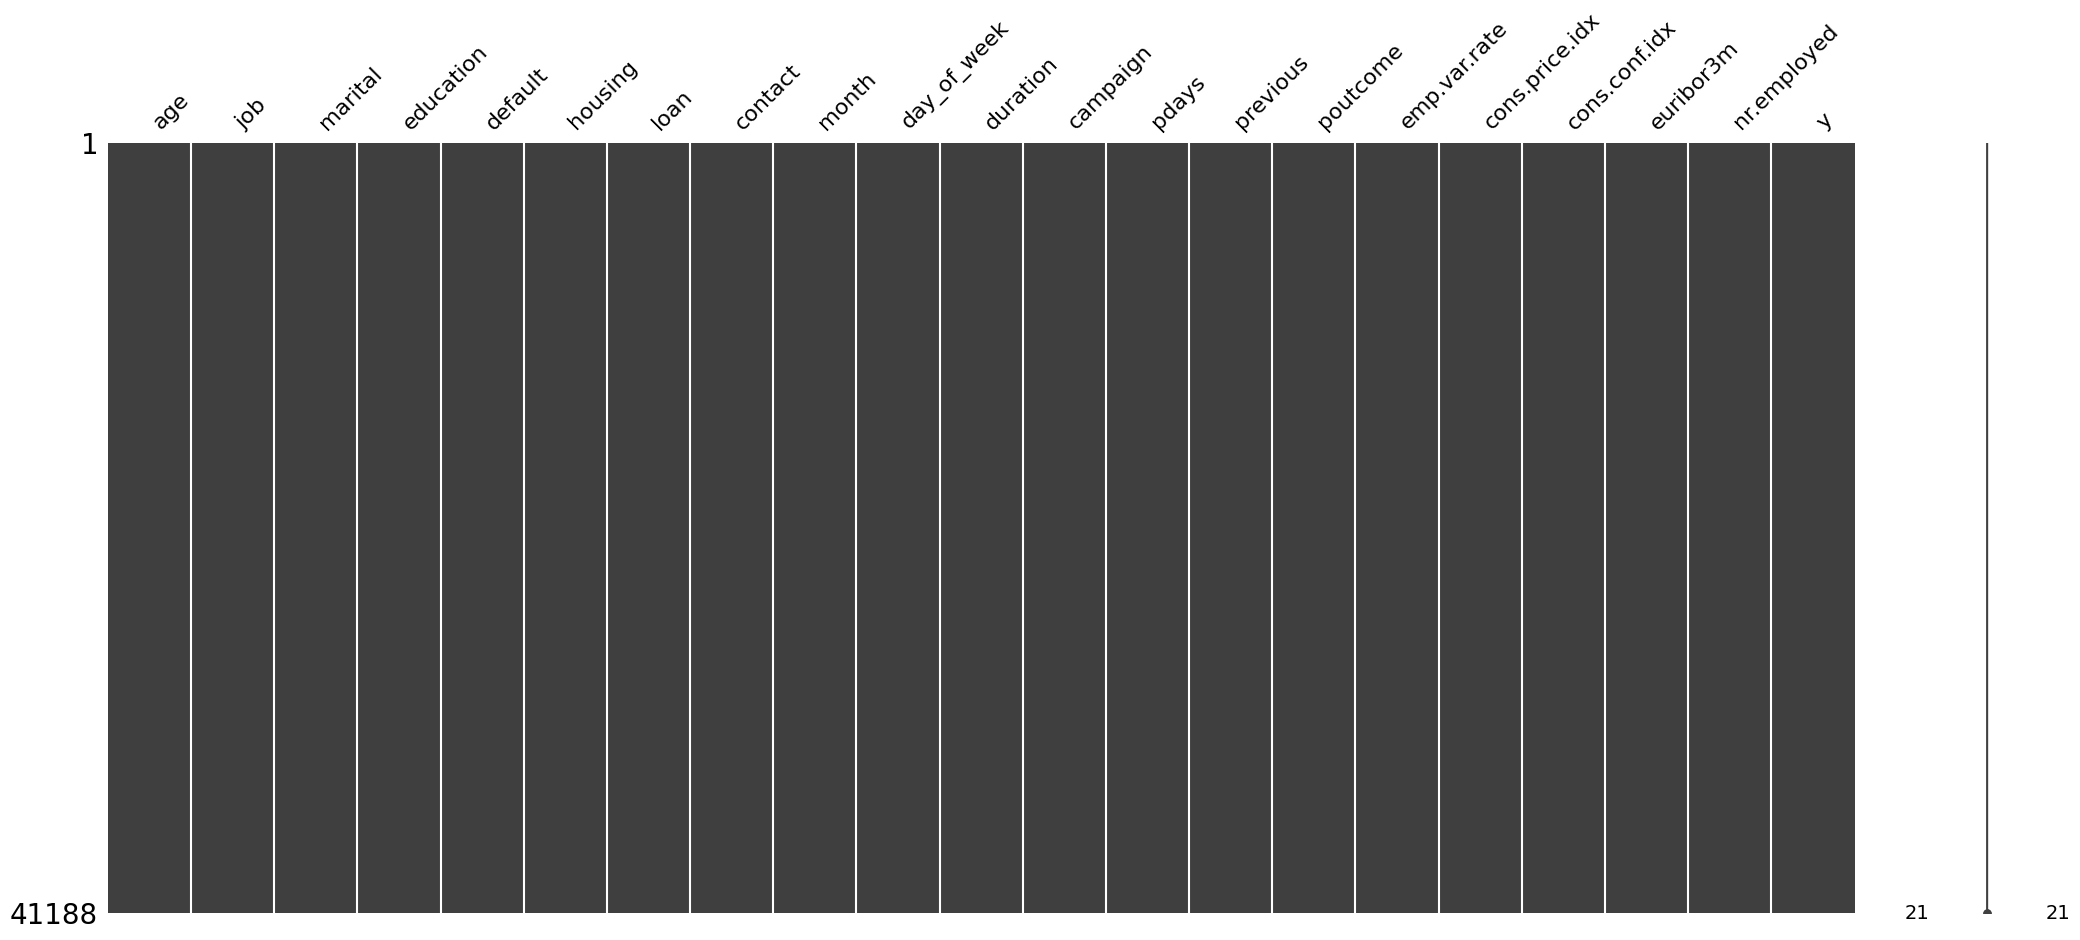

In [18]:
import missingno as msno
msno.matrix(df)        # Eksik değerlerin haritası (beyaz = eksik)
plt.show()

## Hedef Değişken (Target) Analizi

In [19]:
hedef = 'y'

In [20]:
print(df[hedef].value_counts())          # Her sınıftan kaç tane var

y
no     36548
yes     4640
Name: count, dtype: int64


In [21]:
print(df[hedef].value_counts(normalize=True) * 100)  # Yüzde olarak

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


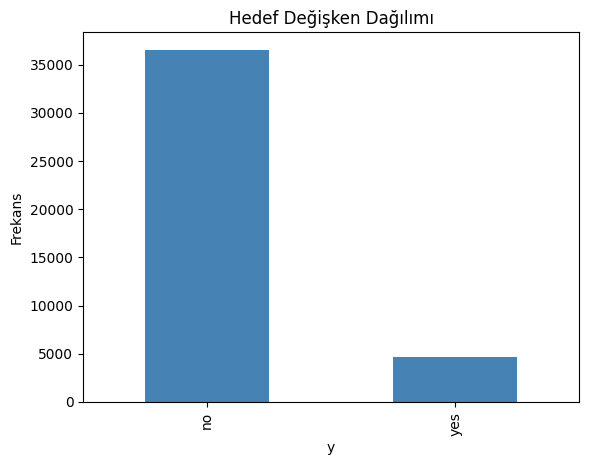

In [22]:
df[hedef].value_counts().plot(kind='bar', color='steelblue')
plt.title('Hedef Değişken Dağılımı')
plt.ylabel('Frekans')
plt.show()


> Sınıf Dengesizliği Var!

Model eğitirken her müşteriyi "no" tahmin etse bile %88,7 doğruluk alır

Ama bu işe yaramaz bir model olur — abone olacak 4.640 kişiyi tamamen kaçırır

Değerlendirmede accuracy değil, AUC-ROC ve F1 kullanmak gerekiyor

## Sayısal Değişken Analizi

In [24]:
sayisal_sutunlar = df.select_dtypes(include=[np.number]).columns.tolist()

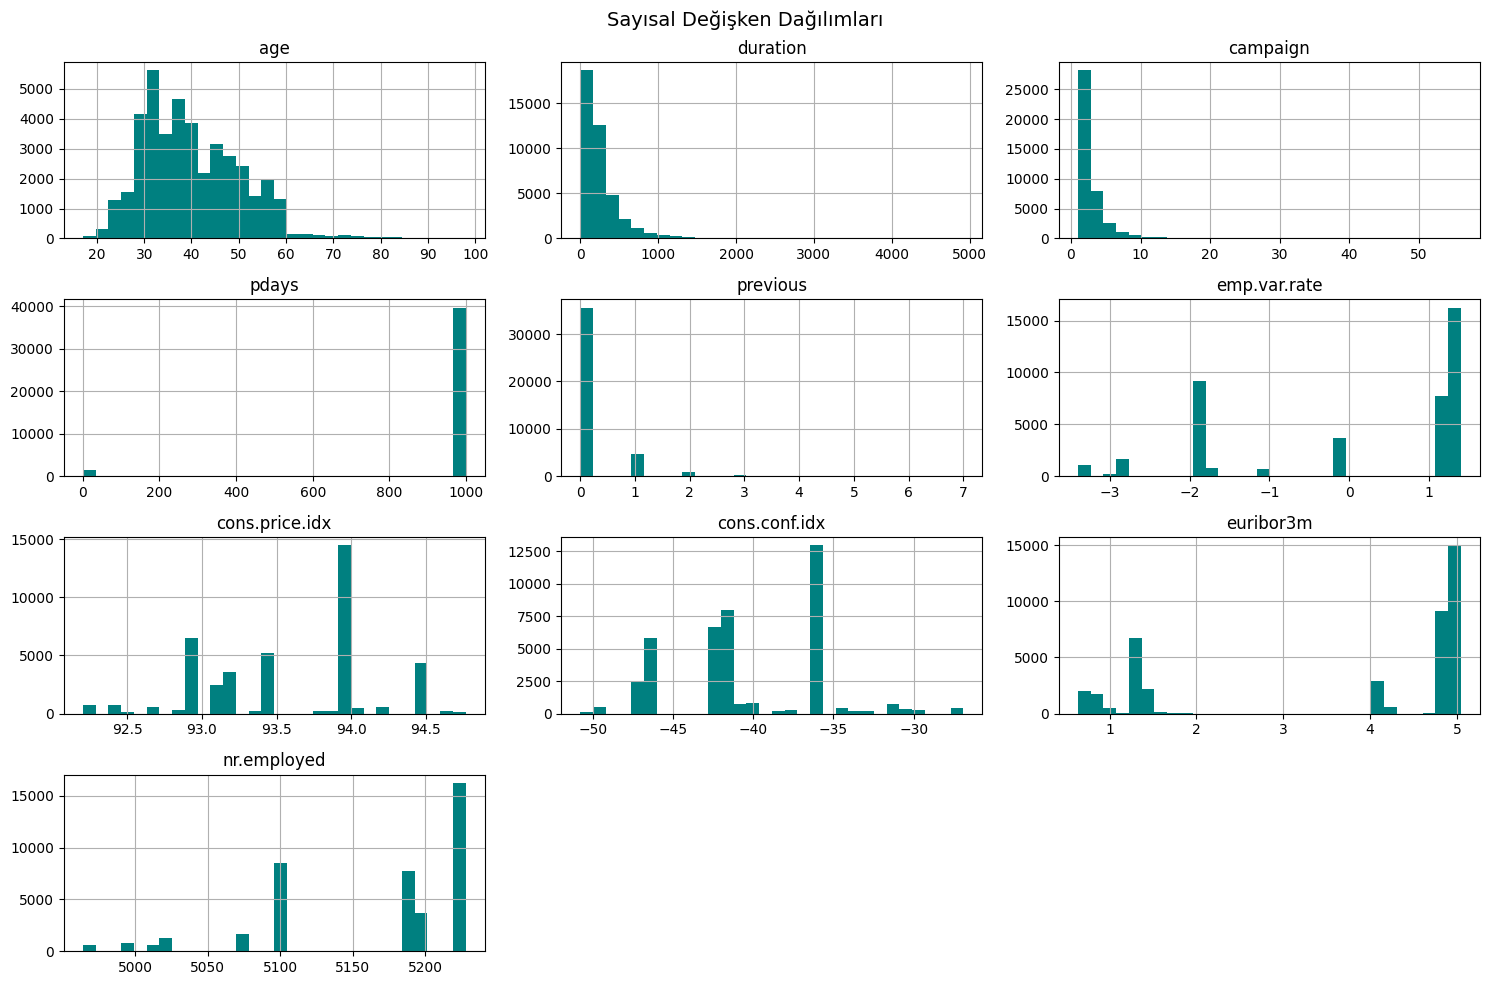

In [25]:
# Histogramlar — dağılım şekline bak
df[sayisal_sutunlar].hist(
    bins=30,          # 30 çubuk
    figsize=(15, 10), # Grafik boyutu (genişlik, yükseklik)
    color='teal'
)
plt.suptitle('Sayısal Değişken Dağılımları', fontsize=14)
plt.tight_layout()   # Grafikler üst üste gelmesin
plt.show()


age → 25-60 yaş arası yoğun, normal dağılıma yakın. 90+ yaş aykırı değerler var ama az.

duration → Sağa çarpık. Çoğu arama kısa (0-500 sn), ama 4000+ saniyelik aramalar da var. Bu değişken en güçlü tahmin edici olacak muhtemelen.

campaign → Çoğu müşteri 1-3 kez aranmış. 50+ kez arananlar aykırı değer.

pdays → Dev bir çubuk 999'da. Yani müşterilerin büyük çoğunluğu hiç aranmamış önceki kampanyada. 999 aslında "veri yok" anlamına geliyor.

previous → Benzer şekilde çoğunluk 0 — önceki kampanyada temas kurulmamış.

emp.var.rate / euribor3m / nr.employed → İki kutuplu dağılım — veri iki farklı ekonomik dönemden geliyor (2008 krizi öncesi ve sonrası).

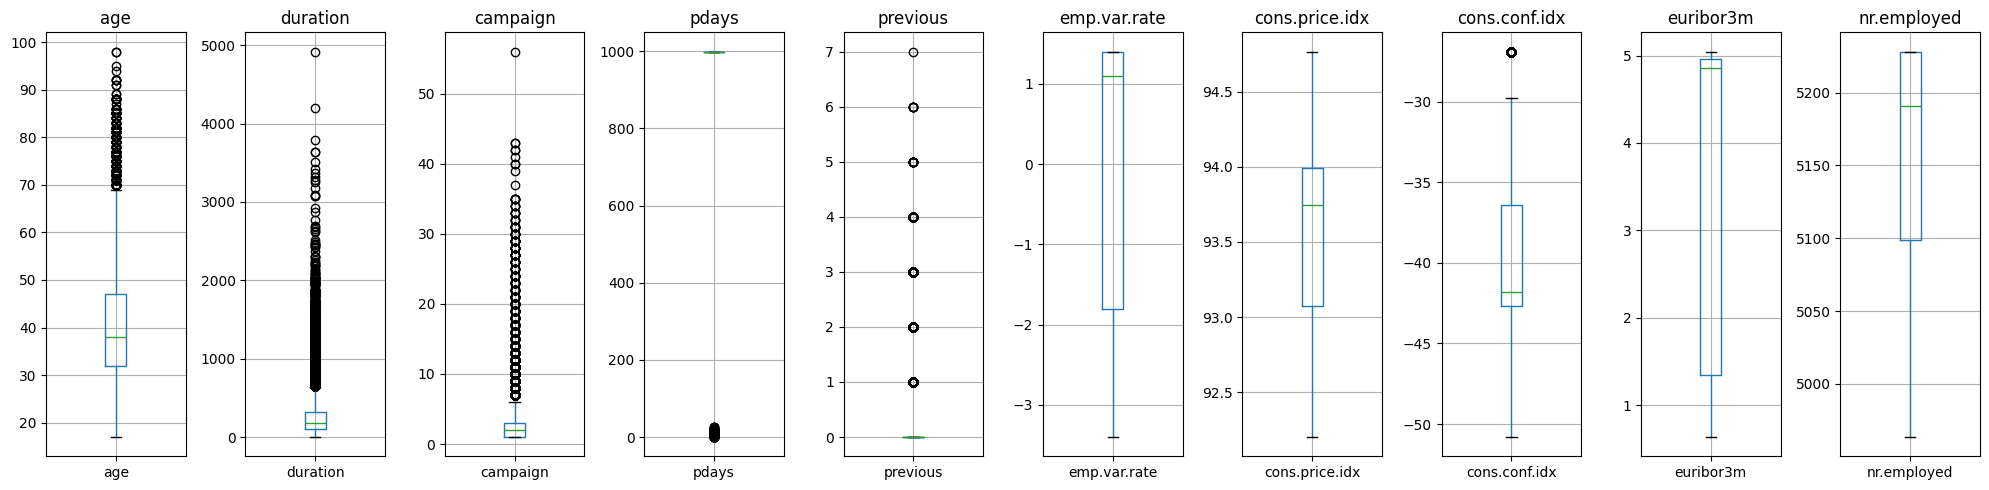

In [26]:
# Box plot — aykırı değerler
fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(20, 5))
# fig    → tüm grafik alanı
# axes   → her sütun için ayrı grafik kutusu

for i, sutun in enumerate(sayisal_sutunlar):
    # enumerate → hem index (i) hem değer (sutun) ver
    df.boxplot(column=sutun, ax=axes[i])
    axes[i].set_title(sutun)
plt.tight_layout()
plt.show()


duration → Çok fazla aykırı değer

campaign → Fazla aykırı değer

pdays → 999 değerleri baskın

previous → Az ama var

age → Makul

In [27]:
print("pdays=999 olan satır sayısı:", (df["pdays"] == 999).sum())
print("Oran:", (df["pdays"] == 999).mean().round(3))

pdays=999 olan satır sayısı: 39673
Oran: 0.963


41.188 müşterinin 39.673'ü (%96,3) daha önce hiç aranmamış.

Yani pdays sütununda gerçek bir "kaç gün geçti" bilgisi sadece %3,7'lik bir kesimde var. Geri kalanı için 999 = "bilgi yok".

In [28]:
df["was_contacted_before"] = (df["pdays"] != 999).astype(int)
print(df["was_contacted_before"].value_counts())

was_contacted_before
0    39673
1     1515
Name: count, dtype: int64


pdays değişkeninin %96,3'ü 999 (hiç aranmadı) değerini taşıdığından, bu sütundan was_contacted_before adlı binary bir özellik türetilmiştir.

## Kategorik Değişken Analizi


=== job ===
Benzersiz değer sayısı: 12
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
Name: count, dtype: int64

=== marital ===
Benzersiz değer sayısı: 4
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

=== education ===
Benzersiz değer sayısı: 8
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

=== default ===
Benzersiz değer sayısı: 3
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

=== housing ===
Benzersiz değer sayısı: 3
housing
yes        21576
no         18622
unknown      990
Name: co

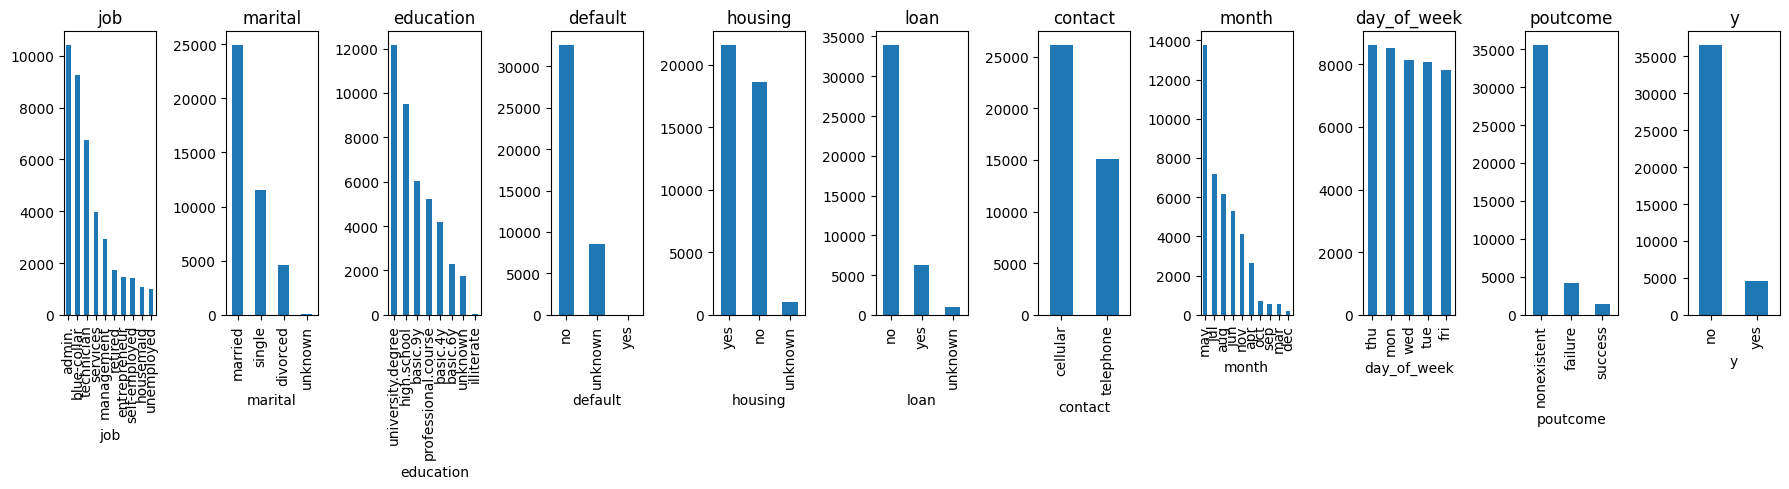

In [30]:
kategorik_sutunlar = df.select_dtypes(include=['object', 'category']).columns

for sutun in kategorik_sutunlar:
    print(f"\n=== {sutun} ===")
    print(f"Benzersiz değer sayısı: {df[sutun].nunique()}")
    # nunique() → kaç farklı kategori var
    print(df[sutun].value_counts().head(10))  # En sık 10 değer

# Bar grafik
fig, axes = plt.subplots(1, len(kategorik_sutunlar), figsize=(18, 5))
for i, sutun in enumerate(kategorik_sutunlar):
    df[sutun].value_counts().head(10).plot(kind='bar', ax=axes[i])
    axes[i].set_title(sutun)
plt.tight_layout()
plt.show()


👔 job

* admin, blue-collar, technician en kalabalık 3 grup
* housemaid, unemployed az temsil edilmiş
* Modelde meslek grupları arasında davranış farkı beklenebilir


💍 marital

* %60 evli — veri seti evli bireyler ağırlıklı
* unknown sadece 80 kişi, ihmal edilebilir


🎓 education

* university.degree ve high.school baskın
* illiterate çok az → modelde sorun çıkarabilir, unknown ile birleştirilebilir


⚠️ default (temerrüt)

* "yes" neredeyse yok! — çok az müşteri temerrütte
* unknown çok fazla (yaklaşık 8.000)
* Bu sütun modele fazla katkı sağlamayabilir


📞 contact

* cellular %63, telephone %37
* Cep telefonuyla aramanın dönüşüme etkisi incelenebilir


📅 month

* may baskın → kampanyalar ağırlıklı mayısta yapılmış
* dec, sep çok az veri → bu aylardaki tahminler güvenilmez olabilir


🏆 poutcome

* %96 "nonexistent" — pdays analizindeki 999 bulgusunu doğruluyor
* "success" çok az ama abone olma oranı yüksek olacak büyük ihtimalle

In [31]:
print(df.groupby("poutcome")["y"].value_counts(normalize=True).mul(100).round(1))

poutcome     y  
failure      no     85.8
             yes    14.2
nonexistent  no     91.2
             yes     8.8
success      yes    65.1
             no     34.9
Name: proportion, dtype: float64


Önceki kampanyada "evet" diyen müşteri, bu sefer de %65 ihtimalle "evet" diyor!

Genel ortalama %11,3 iken success grubunda bu oran 6 kat daha yüksek.

Bu şu anlama gelir:

* Banka önce bu segmentteki müşterileri aramalı
* poutcome değişkeni modelin en önemli özelliklerinden biri olacak
* Daha önce reddeden (failure) müşteriler bile genel ortalamadan (%14,2 > %11,3) daha iyi

## Korelasyon Analizi

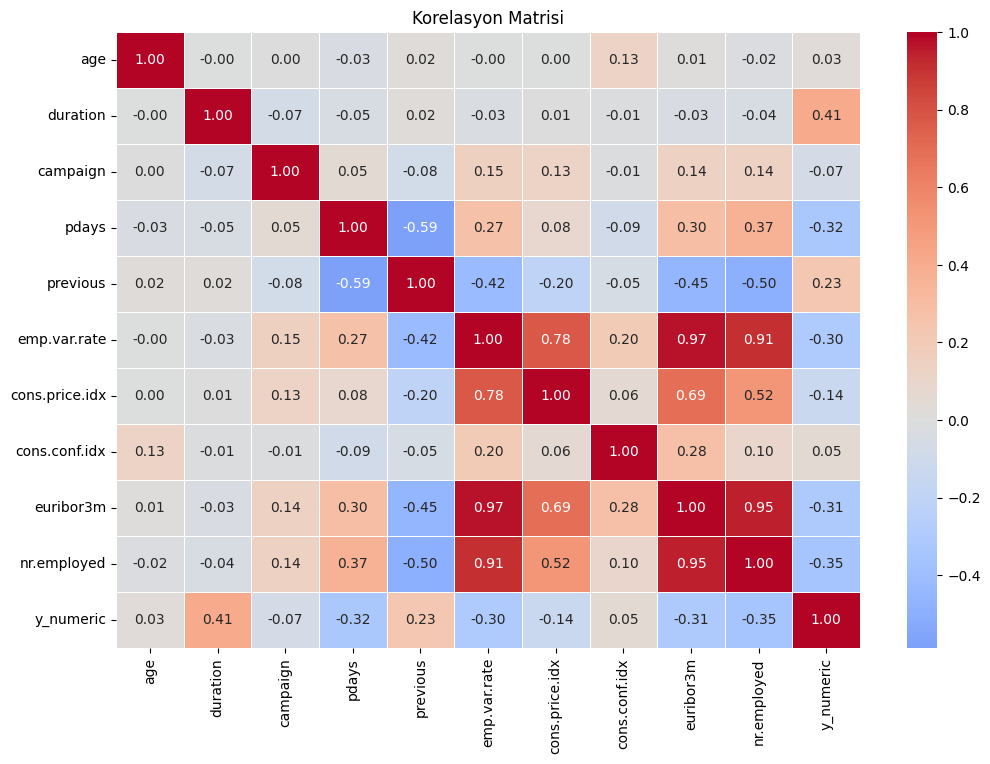

y_numeric         1.000000
duration          0.405274
nr.employed       0.354678
pdays             0.324914
euribor3m         0.307771
emp.var.rate      0.298334
previous          0.230181
cons.price.idx    0.136211
campaign          0.066357
cons.conf.idx     0.054878
age               0.030399
Name: y_numeric, dtype: float64


In [42]:
sayisal_sutunlar = ["age", "duration", "campaign", "pdays", "previous", 
                    "emp.var.rate", "cons.price.idx", "cons.conf.idx", 
                    "euribor3m", "nr.employed", "y_numeric"]

# y_numeric oluştur
df["y_numeric"] = df["y"].map({"yes": 1, "no": 0})

# Korelasyon matrisi
korelasyon = df[sayisal_sutunlar].corr()

# Isı haritası
plt.figure(figsize=(12, 8))
sns.heatmap(
    korelasyon,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Korelasyon Matrisi')
plt.show()

# Hedefle korelasyon
hedef_korelasyon = korelasyon["y_numeric"].abs().sort_values(ascending=False)
print(hedef_korelasyon)

|Değişken | Korelasyon| Yorum| 
|-------|-------|-------|
| duration | 0.41 | Arama uzadıkça abone olma ihtimali artıyor|
| nr.employed | -0.35 | İstihdam yüksekken insanlar mevduata ilgi göstermiyor| 
| pdays | -0.32 |Daha önce aranmış müşteriler daha ilgili|
|euribor3m|-0.31|Faiz düşükken mevduat daha cazip|
|emp.var.rate|-0.30|Ekonomi kötüleşince mevduata yöneliş artıyor|


Makro ekonomik değişkenler birbirleriyle çok yüksek korelasyonlu:

* emp.var.rate ↔ euribor3m = 0.97 🔴
* emp.var.rate ↔ nr.employed = 0.91 🔴
* euribor3m ↔ nr.employed = 0.95 🔴

Bu değişkenler aynı ekonomik dönemin farklı ölçümleri — hepsi aynı şeyi anlatıyor.

## Çift Değişkenli Analiz (Pairplot)

In [ ]:
sayisal_sutunlar

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y_numeric']

In [46]:
df["y_numeric"] = df["y"].map({"yes": 1, "no": 0})
print(df["y_numeric"].head())

0    0
1    0
2    0
3    0
4    0
Name: y_numeric, dtype: int64


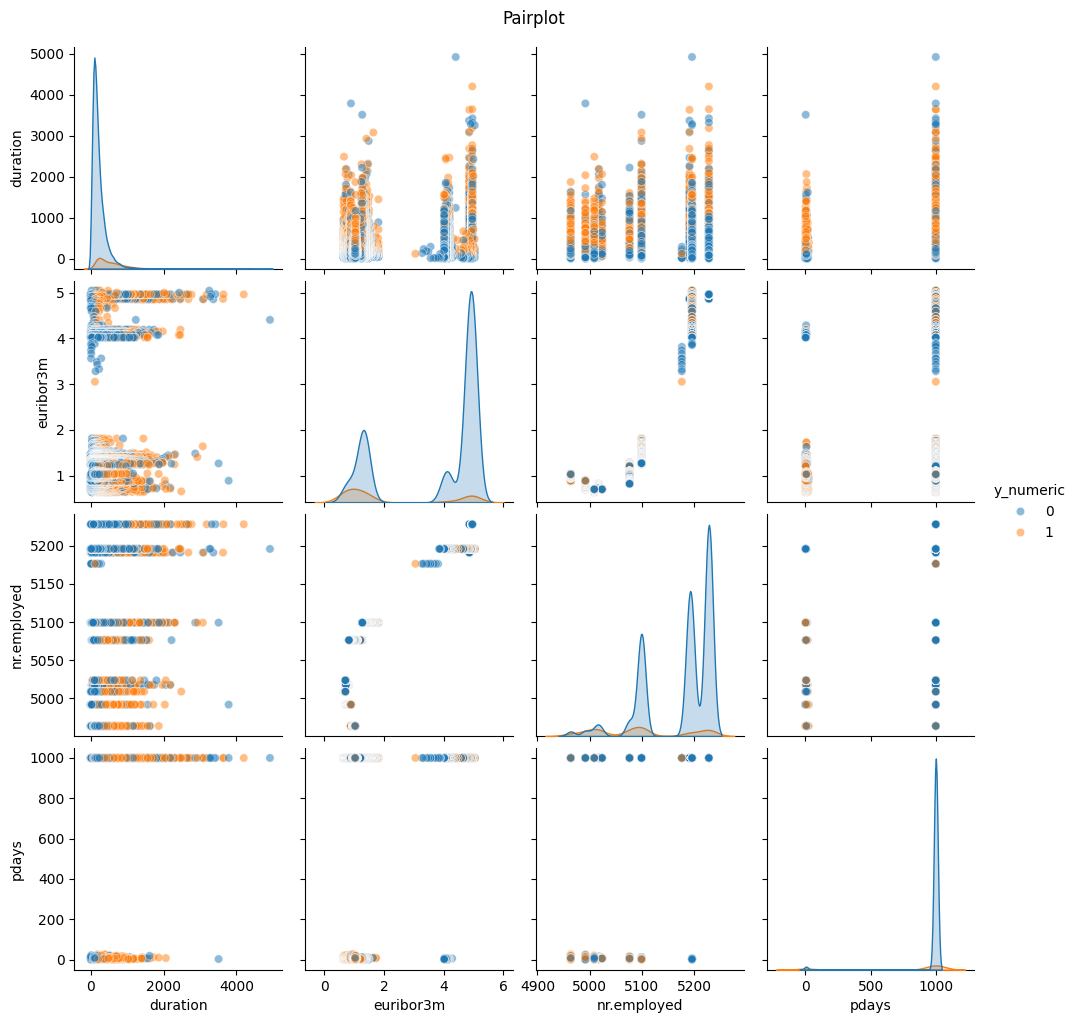

In [51]:
secili = ["duration", "euribor3m", "nr.employed", "pdays", "y_numeric"]

sns.pairplot(
    df[secili],
    hue="y_numeric",
    diag_kind="kde",
    plot_kws={"alpha": 0.5}
)
plt.suptitle("Pairplot", y=1.02)
plt.show()

🔵 Mavi = abone olmadı (0) | 🟠 Turuncu = abone oldu (1)

*duration (arama süresi)*

* Turuncu noktalar (yes) daha uzun aramalarda yoğunlaşmış
* Kısa aramalarda neredeyse hiç turuncu yok → kısa arama = muhtemelen ret

*euribor3m (faiz oranı)*

* Turuncu noktalar düşük faiz bölgesinde (1-2) toplanmış
* Yüksek faizde (4-5) neredeyse hepsi mavi → faiz yüksekken kimse mevduat açmıyor

*nr.employed (çalışan sayısı)*

* Turuncu noktalar düşük istihdam döneminde (5000-5100) yoğun
* Yüksek istihdamda (5200+) çoğunluk mavi → ekonomi iyi gidince mevduat ilgisi azalıyor

*pdays*

* Neredeyse her şey 999'da yığılmış (daha önce hiç aranmadı)
* 0-200 arası turuncu nokta oranı görece yüksek → daha önce aranmış müşteriler daha ilgili

# VERİ TEMİZLEME

## Tekrar Eden Satırları Silme

In [52]:
print(f"Tekrar eden satır sayısı: {df.duplicated().sum()}")

df = df.drop_duplicates()
print(f"Temizlendikten sonra boyut: {df.shape}")

Tekrar eden satır sayısı: 12
Temizlendikten sonra boyut: (41176, 23)


## Aykırı Değer (Outlier) İşleme

In [53]:
def iqr_ile_sinirla(df, sutun):
    Q1 = df[sutun].quantile(0.25)
    Q3 = df[sutun].quantile(0.75)
    IQR = Q3 - Q1
    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR
    df[sutun] = df[sutun].clip(lower=alt_sinir, upper=ust_sinir)
    return df

# duration ve pdays hariç uygula
kirpilacak_sutunlar = ["age", "campaign", "previous", 
                       "emp.var.rate", "cons.price.idx", 
                       "cons.conf.idx", "euribor3m", "nr.employed"]

for sutun in kirpilacak_sutunlar:
    df = iqr_ile_sinirla(df, sutun)

print("Aykırı değerler sınırlandı ")

Aykırı değerler sınırlandı 


## VERİ DÖNÜŞÜMÜ (Feature Engineering)

### Kategorik Kodlama

In [54]:
# Sıralı kategorik → Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["education"] = le.fit_transform(df["education"])
# basic.4y < basic.6y < basic.9y < high.school < university.degree gibi sıra var

# Sırasız kategorikler → One-Hot Encoding
kategorik_sutunlar = ["job", "marital", "default", "housing", "loan",
                      "contact", "month", "day_of_week", "poutcome"]

df = pd.get_dummies(
    df,
    columns=kategorik_sutunlar,
    drop_first=True,
    dtype=int
)

print(df.shape)
print(df.head())


(41176, 50)
    age  education  duration  campaign  pdays  previous  emp.var.rate  \
0  56.0          0       261         1    999         0           1.1   
1  57.0          3       149         1    999         0           1.1   
2  37.0          3       226         1    999         0           1.1   
3  40.0          1       151         1    999         0           1.1   
4  56.0          3       307         1    999         0           1.1   

   cons.price.idx  cons.conf.idx  euribor3m  ...  month_may month_nov  \
0          93.994          -36.4      4.857  ...          1         0   
1          93.994          -36.4      4.857  ...          1         0   
2          93.994          -36.4      4.857  ...          1         0   
3          93.994          -36.4      4.857  ...          1         0   
4          93.994          -36.4      4.857  ...          1         0   

   month_oct  month_sep  day_of_week_mon  day_of_week_thu  day_of_week_tue  \
0          0          0         

In [55]:
print(df.columns.tolist())
print(df["y"].value_counts())

['age', 'education', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'was_contacted_before', 'y_numeric', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success']
y
no     36537
yes     4639
Name: count, dtype: int64


### Yeni Özellik Türetme

In [58]:
# Temas yoğunluğu
df["contact_intensity"] = df["campaign"] / (df["previous"] + 1)

# Ekonomik baskı skoru
df["economic_pressure"] = df["euribor3m"] * df["emp.var.rate"]

# Arama süresi kategorisi — NaN sorunu için include_lowest ekle
df["duration_cat"] = pd.cut(
    df["duration"],
    bins=[0, 100, 300, 600, 9999],
    labels=[0, 1, 2, 3],
    include_lowest=True   # 0 değerini de dahil et
).astype(int)

print(df[["was_contacted_before", "contact_intensity", 
          "economic_pressure", "duration_cat"]].head())

   was_contacted_before  contact_intensity  economic_pressure  duration_cat
0                     0                1.0             5.3427             1
1                     0                1.0             5.3427             1
2                     0                1.0             5.3427             1
3                     0                1.0             5.3427             1
4                     0                1.0             5.3427             2


* was_contacted_before → 0 (ilk 5 müşteri hiç aranmamış, beklenen)
* contact_intensity → 1.0 (1 kez arandılar, önceki temas yok → 1/1=1)
* economic_pressure → 5.34 (euribor3m × emp.var.rate = 4.857 × 1.1)
* duration_cat → 1 veya 2 (100-300 sn arası aramalar)

# VERİ BÖLME (Train / Validation / Test)

In [59]:
from sklearn.model_selection import train_test_split

# y sütununu ve y_numeric'i çıkar
X = df.drop(columns=["y", "y_numeric"])
y = df["y"]

# %80 eğitim, %20 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# eğitim verisini %80/%20 → validation ayır
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(f"Eğitim   : {X_train.shape}")
print(f"Doğrulama: {X_val.shape}")
print(f"Test     : {X_test.shape}")

Eğitim   : (26352, 51)
Doğrulama: (6588, 51)
Test     : (8236, 51)


# SINIF DENGESİZLİĞİ (Imbalanced Data)

In [60]:
print("Orijinal dağılım:")
print(y_train.value_counts())
print(f"\nOran: {y_train.value_counts(normalize=True).mul(100).round(1).to_dict()}")


Orijinal dağılım:
y
no     23383
yes     2969
Name: count, dtype: int64

Oran: {'no': 88.7, 'yes': 11.3}


# Hepsini bir arada kontrol et

In [62]:

assert X_train.isnull().sum().sum() == 0, "Eğitim setinde eksik değer var!"
assert X_test.isnull().sum().sum()  == 0, "Test setinde eksik değer var!"
# assert → koşul yanlışsa hata ver ve dur

print("Eğitim seti boyutu :", X_train.shape)
print("Doğrulama seti     :", X_val.shape)
print("Test seti boyutu   :", X_test.shape)
print("Özellik sayısı     :", X_train.shape[1])
print("Sınıf dağılımı:\n",   y_train.value_counts(normalize=True))


Eğitim seti boyutu : (26352, 51)
Doğrulama seti     : (6588, 51)
Test seti boyutu   : (8236, 51)
Özellik sayısı     : 51
Sınıf dağılımı:
 y
no     0.887333
yes    0.112667
Name: proportion, dtype: float64


# MODEL EĞİTİMİ

In [68]:
from sklearn.ensemble import RandomForestClassifier

In [69]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)


In [70]:
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# TEST

In [73]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

In [74]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [75]:
# 1. Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

          no       0.99      0.89      0.93      7308
         yes       0.50      0.90      0.64       928

    accuracy                           0.89      8236
   macro avg       0.74      0.89      0.79      8236
weighted avg       0.93      0.89      0.90      8236



In [79]:
# 2. AUC-ROC
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob), 4))

AUC-ROC: 0.9496


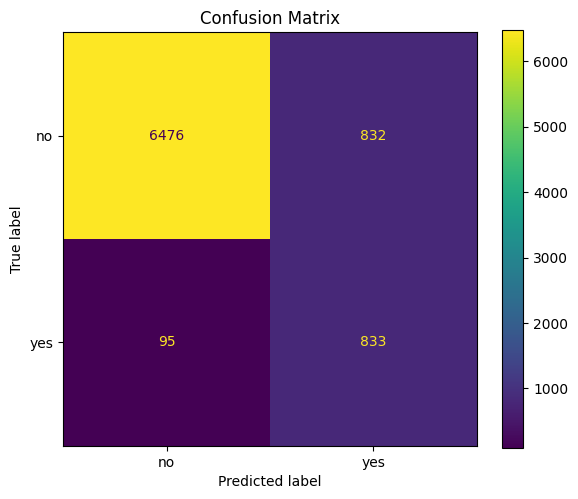

In [77]:
# 3. Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

*auc-roc*
* AUC-ROC = 0.9496

*Confusion Matrix*
* Abone olacak 928 müşterinin 833'ünü yakaladı (%90) 
* Sadece 95 kişiyi kaçırdı — bu bankacılık için çok iyi
* 832 kişi gereksiz arandı ama bu kabul edilebilir

*Metrikler*
* Precision = 0.50 → "yes" dediğinin yarısı gerçekten yes
* Recall = 0.90 → Abone olacakların %90'ı yakalandı 
* F1-Score = 0.64 → Dengesiz veri için iyi

Precision düşük görünse de sorun değil — bankada amaç potansiyel müşteriyi kaçırmamak. 95 kişiyi kaçırmak, 832 kişiyi gereksiz aramaktan çok daha maliyetli.

# Özellik önemi

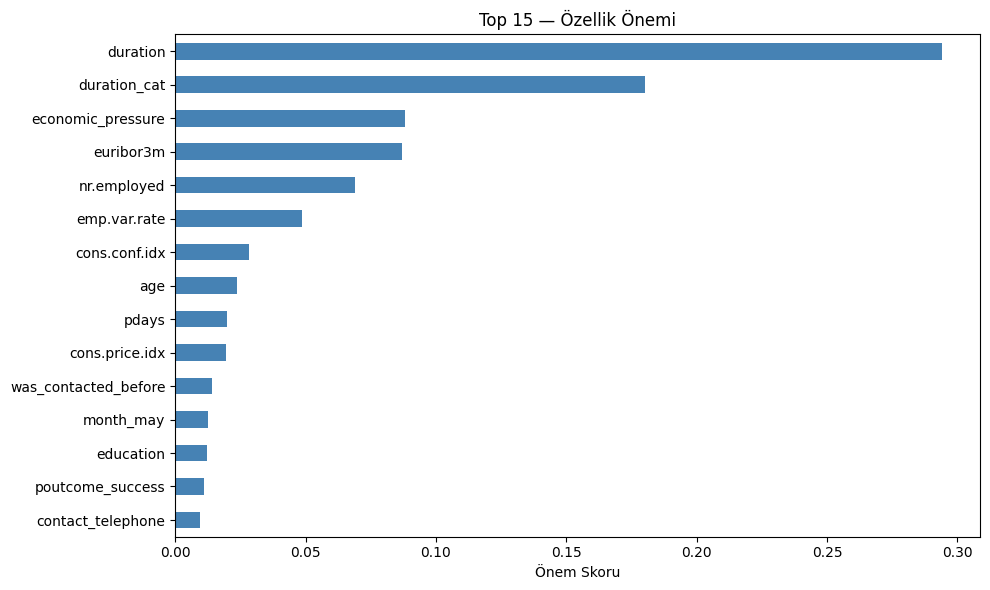

duration             0.293993
duration_cat         0.180098
economic_pressure    0.088194
euribor3m            0.086819
nr.employed          0.069009
emp.var.rate         0.048764
cons.conf.idx        0.028415
age                  0.023700
pdays                0.019747
cons.price.idx       0.019580
dtype: float64


In [80]:
feat_imp = pd.Series(
    model.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

# Top 15
plt.figure(figsize=(10, 6))
feat_imp.head(15).sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 15 — Özellik Önemi")
plt.xlabel("Önem Skoru")
plt.tight_layout()
plt.show()

print(feat_imp.head(10))

In [82]:
import pickle

# Modeli kaydet
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# Sütun isimlerini kaydet
with open("columns.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)


print("Sütun sayısı:", len(X_train.columns))

Sütun sayısı: 51
